### 1.Preparacion y Division de Datos


In [ ]:
# @title Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title Importar librerías Ejercicio 1
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Librerias cargadas OK")

Librerias cargadas OK


In [ ]:
# @title Configurar Rutas
# ====================================================
RUTA_DATASET_DRIVE = '/content/drive/MyDrive/Animales'
RUTA_SALIDA        = '/content/drive/MyDrive/dataset_split'
PROPORCION_ENTRENAMIENTO = 0.80
TAM_IMAGEN = (512, 512)
TAM_BATCH = 32
# ====================================================

ruta_dataset = Path(RUTA_DATASET_DRIVE)
ruta_salida  = Path(RUTA_SALIDA)

if ruta_dataset.exists():
    print(f"OK: carpeta encontrada en {RUTA_DATASET_DRIVE}")
else:
    print(f"ERROR: no se encuentra {RUTA_DATASET_DRIVE}")

OK: carpeta encontrada en /content/drive/MyDrive/Animales


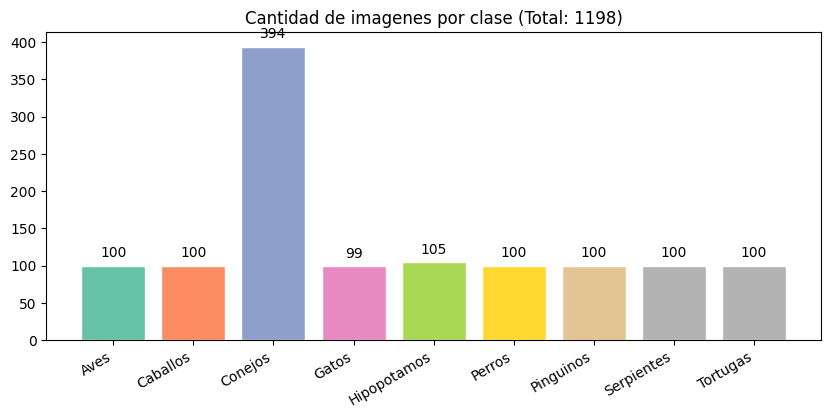


--- train ---
Aves: 79
Caballos: 79
Conejos: 79
Gatos: 79
Hipopotamos: 79
Perros: 79
Pinguinos: 79
Serpientes: 79
Tortugas: 0

--- test ---
Aves: 20
Caballos: 20
Conejos: 20
Gatos: 20
Hipopotamos: 20
Perros: 20
Pinguinos: 20
Serpientes: 20
Tortugas: 0


In [ ]:
# @title Contar clases y Graficar balance

CLASES = sorted([d.name for d in ruta_dataset.iterdir() if d.is_dir()])
conteo = {}
for i, clase in enumerate(CLASES):
    imagenes = [f for f in (ruta_dataset / clase).glob('*.*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    conteo[clase] = len(imagenes)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(conteo.keys(), conteo.values(), color=plt.cm.Set2(np.linspace(0, 1, len(CLASES))), edgecolor='white')
ax.bar_label(bars, padding=4)
ax.set_title('Cantidad de imagenes por clase (Total: {})'.format(sum(conteo.values())))
plt.xticks(rotation=30, ha='right')
plt.show()
for split in ['train', 'test']:
    print(f"\n--- {split} ---")
    for clase in CLASES:
        n = len(list((ruta_salida / split / clase).glob('*.*')))
        print(f"{clase}: {n}")

In [ ]:
# @title Configuración global

NUM_CLASSES = 8          # <-- poné acá cuántas clases querés usar (8, 9, las que sean)
IMAGENES_POR_CLASE = 99 # <-- cupo por clase (si una tiene menos, usa las que haya)
# TAM_IMAGEN = (512, 512)    # <-- tamaño de imagen (Ya definida en el bloque anterior)

todas_las_clases = sorted([c.name.strip() for c in ruta_dataset.iterdir() if c.is_dir()])
print(f"Clases disponibles en Drive ({len(todas_las_clases)}):", todas_las_clases)

CLASES = todas_las_clases[:NUM_CLASSES]  # agarra las primeras N, deja el resto afuera

print(f"\nClases usadas ({len(CLASES)}):", CLASES)
if len(todas_las_clases) > NUM_CLASSES:
    descartadas = todas_las_clases[NUM_CLASSES:]
    print(f"Clases descartadas:", descartadas)

Clases disponibles en Drive (9): ['Aves', 'Caballos', 'Conejos', 'Gatos', 'Hipopotamos', 'Perros', 'Pinguinos', 'Serpientes', 'Tortugas']

Clases usadas (8): ['Aves', 'Caballos', 'Conejos', 'Gatos', 'Hipopotamos', 'Perros', 'Pinguinos', 'Serpientes']
Clases descartadas: ['Tortugas']


In [ ]:
# @title Split en carpetas (con normalización Unicode)
import shutil, random, unicodedata

def normalizar(s):
    return unicodedata.normalize('NFC', s.strip())

for split in ['train', 'test']:
    if (ruta_salida / split).exists():
        shutil.rmtree(ruta_salida / split)
    for clase in CLASES:
        (ruta_salida / split / clase).mkdir(parents=True, exist_ok=True)

for clase in CLASES:
    carpeta_real = next(c for c in ruta_dataset.iterdir() if normalizar(c.name) == normalizar(clase))
    imagenes = [f for f in carpeta_real.glob('*.*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    random.shuffle(imagenes)

    n_usar = min(IMAGENES_POR_CLASE, len(imagenes))
    imagenes = imagenes[:n_usar]
    n_train = int(len(imagenes) * PROPORCION_ENTRENAMIENTO)

    for img in imagenes[:n_train]:
        shutil.copy(img, ruta_salida / 'train' / clase / img.name)
    for img in imagenes[n_train:]:
        shutil.copy(img, ruta_salida / 'test' / clase / img.name)

print("Split listo")

Split listo


### 2.Configuracion de la Capa de Salida

In [ ]:
# @title Cargar datasets con Keras (train/test) + one-hot


train_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_salida / 'train',
    labels='inferred',
    label_mode='categorical',
    class_names=CLASES,
    image_size=TAM_IMAGEN,
    batch_size=TAM_BATCH,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_salida / 'test',
    labels='inferred',
    label_mode='categorical',
    class_names=CLASES,
    image_size=TAM_IMAGEN,
    batch_size=TAM_BATCH,
    shuffle=False
)

print("Clases (orden = posición en el one-hot):", train_ds.class_names)

for imagenes, etiquetas in train_ds.take(1):
    print("Forma del lote de imágenes:", imagenes.shape)
    print("Forma de etiquetas (one-hot):", etiquetas.shape)

Found 632 files belonging to 8 classes.
Found 160 files belonging to 8 classes.
Clases (orden = posición en el one-hot): ['Aves', 'Caballos', 'Conejos', 'Gatos', 'Hipopotamos', 'Perros', 'Pinguinos', 'Serpientes']
Forma del lote de imágenes: (32, 512, 512, 3)
Forma de etiquetas (one-hot): (32, 8)


# @title Verificación de variables actuales
print("NUM_CLASSES =", NUM_CLASSES)
print("TAM_IMAGEN =", TAM_IMAGEN)
print("CLASES =", CLASES)
print("Cantidad de clases en CLASES =", len(CLASES))

In [ ]:
# @title Verificación de variables actuales
print("NUM_CLASSES =", NUM_CLASSES)
print("TAM_IMAGEN =", TAM_IMAGEN)
print("CLASES =", CLASES)
print("Cantidad de clases en CLASES =", len(CLASES))

NUM_CLASSES = 8
TAM_IMAGEN = (512, 512)
CLASES = ['Aves', 'Caballos', 'Conejos', 'Gatos', 'Hipopotamos', 'Perros', 'Pinguinos', 'Serpientes']
Cantidad de clases en CLASES = 8


In [ ]:
# @title Normalización y data augmentation

# Capa de normalización: pasa los píxeles de 0-255 a 0-1 (ayuda mucho a que converja)
normalizacion = tf.keras.layers.Rescaling(1./255)

# Data augmentation: como tenemos pocas imágenes por clase (~80), esto genera
# variaciones (flip, rotación, zoom) para que la red no memorice de más
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Optimización de performance: cachear y prefetch para que no sea el cuello de botella
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# @title Modelo 1: CNN Custom desde cero (bloques configurables)

# ---- ACÁ CONFIGURÁS LOS BLOQUES ----
# Cada número es la cantidad de filtros de ese bloque Conv2D+MaxPooling.
# La cantidad de bloques = la cantidad de elementos de esta lista.
FILTROS_POR_BLOQUE = [32, 64, 128, 128, 256]  # <-- 5 bloques. Agregá/sacá números para cambiar la cantidad
# -------------------------------------

modelo_custom = tf.keras.Sequential()
modelo_custom.add(tf.keras.layers.Input(shape=(TAM_IMAGEN[0], TAM_IMAGEN[1], 3)))
modelo_custom.add(data_augmentation)
modelo_custom.add(normalizacion)

tam_actual = TAM_IMAGEN[0]
for i, filtros in enumerate(FILTROS_POR_BLOQUE):
    modelo_custom.add(tf.keras.layers.Conv2D(filtros, (3, 3), activation='relu', padding='same'))
    modelo_custom.add(tf.keras.layers.MaxPooling2D((2, 2)))
    tam_actual //= 2
    print(f"Bloque {i+1}: {filtros} filtros -> tamaño de imagen queda en {tam_actual}x{tam_actual}")

modelo_custom.add(tf.keras.layers.Flatten())
modelo_custom.add(tf.keras.layers.Dense(256, activation='relu'))
modelo_custom.add(tf.keras.layers.Dropout(0.5))
modelo_custom.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))

modelo_custom.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_custom.summary()

Bloque 1: 32 filtros -> tamaño de imagen queda en 256x256
Bloque 2: 64 filtros -> tamaño de imagen queda en 128x128
Bloque 3: 128 filtros -> tamaño de imagen queda en 64x64
Bloque 4: 128 filtros -> tamaño de imagen queda en 32x32
Bloque 5: 256 filtros -> tamaño de imagen queda en 16x16


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 512, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,315,528 (66.05 MB)

 Trainable params: 17,315,528 (66.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# @title Entrenamiento del Modelo 1 (CNN Custom)

EPOCHS = 60  # <-- variable editable: subí si no converge, bajá si tarda demasiado

# EarlyStopping: si el modelo deja de mejorar en el set de test, corta solo
# y se queda con los mejores pesos (evita overfitting y ahorra tiempo)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

historial_custom = modelo_custom.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 560ms/step - accuracy: 0.1108 - loss: 2.1379 - val_accuracy: 0.1813 - val_loss: 2.0778
Epoch 2/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.1297 - loss: 2.0744 - val_accuracy: 0.2000 - val_loss: 2.0720
Epoch 3/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - accuracy: 0.1408 - loss: 2.0646 - val_accuracy: 0.1688 - val_loss: 2.0529
Epoch 4/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.2041 - loss: 2.0441 - val_accuracy: 0.2000 - val_loss: 2.0281
Epoch 5/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.1978 - loss: 2.0346 - val_accuracy: 0.2125 - val_loss: 1.9673
Epoch 6/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.2294 - loss: 1.9861 - val_accuracy: 0.2875 - val_loss: 1.9357
Epoch 7/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 272ms/step - accuracy: 0.2437 - loss: 1.9684 - val_accuracy: 0.2375 - val_loss: 1.9187
Epoch 8/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.2864 - loss: 1.9394 - val_accuracy: 0

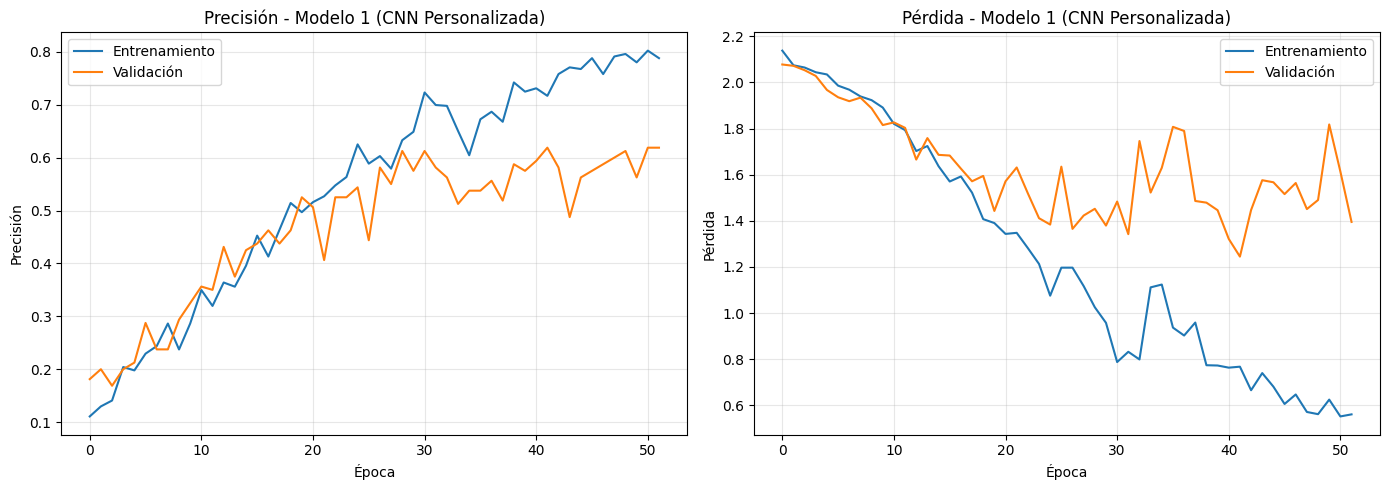

Mejor precisión de validación alcanzada: 61.9%
Mejor pérdida de validación alcanzada: 1.2448


In [ ]:
# @title Gráficos de entrenamiento (Modelo 1)
import matplotlib.pyplot as plt

acc = historial_custom.history['accuracy']
val_acc = historial_custom.history['val_accuracy']
loss = historial_custom.history['loss']
val_loss = historial_custom.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc, label='Entrenamiento')
axes[0].plot(val_acc, label='Validación')
axes[0].set_title('Precisión - Modelo 1 (CNN Personalizada)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Precisión')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(loss, label='Entrenamiento')
axes[1].plot(val_loss, label='Validación')
axes[1].set_title('Pérdida - Modelo 1 (CNN Personalizada)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Pérdida')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(ruta_salida / 'grafico_modelo1.png'), dpi=150)
plt.show()

print(f"Mejor precisión de validación alcanzada: {max(val_acc)*100:.1f}%")
print(f"Mejor pérdida de validación alcanzada: {min(val_loss):.4f}")

###4. Modelo 2: Transfer Learning (Modelo Preentrenado)

In [ ]:
# @title Modelo 2: Transfer Learning con MobileNetV2 (base congelada)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Cargamos la base preentrenada en ImageNet, SIN su cabeza de clasificación original
base_model = MobileNetV2(
    input_shape=(TAM_IMAGEN[0], TAM_IMAGEN[1], 3),
    include_top=False,
    weights='imagenet'
)

# Congelamos la base: sus pesos NO se actualizan en esta primera etapa
base_model.trainable = False

# Data augmentation (mismo criterio que en el Modelo 1, instancia propia)
data_augmentation_tl = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape=(TAM_IMAGEN[0], TAM_IMAGEN[1], 3))
x = data_augmentation_tl(inputs)
x = preprocess_input(x)              # normalización propia de MobileNetV2 (rango -1 a 1, NO 0-1)
x = base_model(x, training=False)    # pasa por la base congelada
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # reemplaza al Flatten
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)  # head nueva, adaptada a tus 8 clases

model_tl = tf.keras.Model(inputs, outputs)

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

/tmp/ipykernel_566/2171192700.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 16, 16, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# @title Entrenamiento del Modelo 2 (Transfer Learning, base congelada)

EPOCHS_TL = 20

early_stop_tl = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_tl = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(ruta_salida / 'model_tl_best.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_tl = model_tl.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_TL,
    callbacks=[early_stop_tl, checkpoint_tl]
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4038 - loss: 1.7611
Epoch 1: val_accuracy improved from None to 0.81250, saving model to /content/drive/MyDrive/dataset_split/model_tl_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_split/model_tl_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 554ms/step - accuracy: 0.5712 - loss: 1.3959 - val_accuracy: 0.8125 - val_loss: 0.6910
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8359 - loss: 0.5461
Epoch 2: val_accuracy improved from 0.81250 to 0.89375, saving model to /content/drive/MyDrive/dataset_split/model_tl_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_split/model_tl_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step - accuracy: 0.8639 - loss: 0.4863 - val_accuracy: 0.8938 - val_loss: 0.3725
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9007 - loss: 0.2981
Epoch 3: val_accuracy did not improve from 0.89375
20/20 ━━━━━━━━━━━

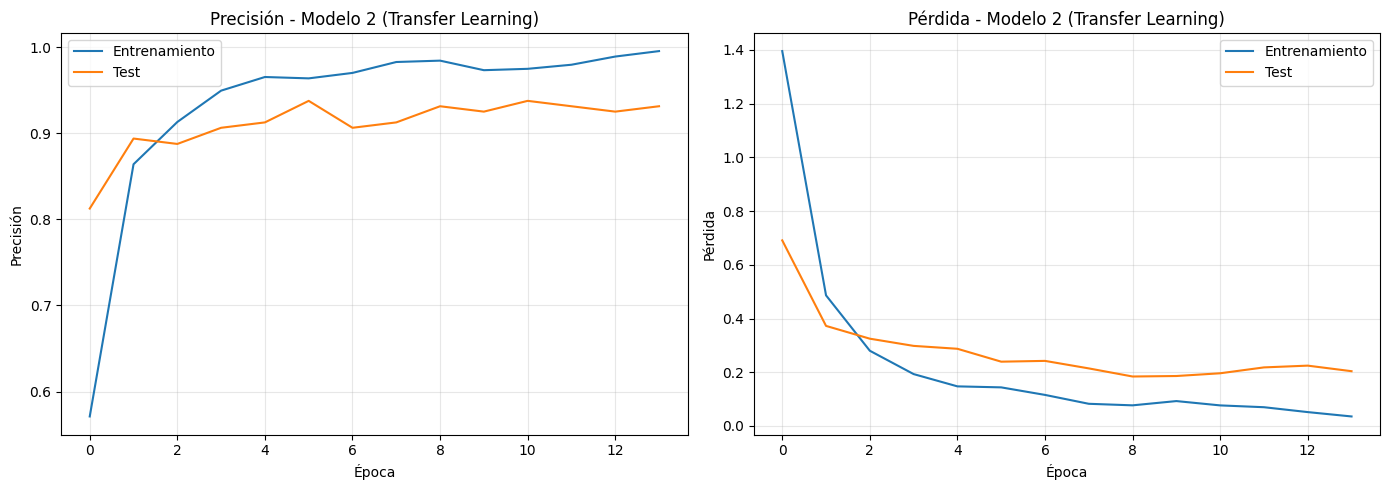

Mejor precisión de validación: 93.75%
Mejor pérdida de validación: 0.1840


In [ ]:
# @title Gráficos de entrenamiento (Modelo 2 - Transfer Learning)
acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(acc, label='Entrenamiento'); axes[0].plot(val_acc, label='Test')
axes[0].set_title('Precisión - Modelo 2 (Transfer Learning)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Precisión')
axes[1].plot(loss, label='Entrenamiento'); axes[1].plot(val_loss, label='Test')
axes[1].set_title('Pérdida - Modelo 2 (Transfer Learning)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Pérdida')
plt.tight_layout()
plt.savefig(str(ruta_salida / 'grafico_modelo2.png'), dpi=150)
plt.show()

print(f"Mejor precisión de validación: {max(val_acc)*100:.2f}%")
print(f"Mejor pérdida de validación: {min(val_loss):.4f}")

In [ ]:
# @title Fine-tuning parcial del Modelo 2

# Descongelamos la base, pero solo las últimas capas (las que capturan
# características más específicas). Las primeras capas (bordes, texturas
# genéricas) se dejan congeladas: esas sirven para cualquier imagen.
base_model.trainable = True

FINE_TUNE_AT = 100  # <-- capas desde el inicio que quedan CONGELADAS (editable)

print(f"Total de capas en la base MobileNetV2: {len(base_model.layers)}")
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompilar es OBLIGATORIO en Keras después de cambiar trainable,
# y con Learning Rate MUY bajo: si usás el mismo LR que antes, los
# gradientes grandes destruyen de golpe los pesos preentrenados.
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

Total de capas en la base MobileNetV2: 154


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 16, 16, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 2,191,432 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
# @title Entrenamiento con Fine-tuning

EPOCHS_FT = 15

early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(ruta_salida / 'model_tl_finetuned_best.keras'),
    monitor='val_accuracy', save_best_only=True, verbose=1
)

history_ft = model_tl.fit(
    train_ds, validation_data=test_ds,
    epochs=EPOCHS_FT, callbacks=[early_stop_ft, checkpoint_ft]
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6010 - loss: 1.3206
Epoch 1: val_accuracy improved from None to 0.93750, saving model to /content/drive/MyDrive/dataset_split/model_tl_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_split/model_tl_finetuned_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 670ms/step - accuracy: 0.6440 - loss: 1.1488 - val_accuracy: 0.9375 - val_loss: 0.1837
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7600 - loss: 0.7635
Epoch 2: val_accuracy improved from 0.93750 to 0.94375, saving model to /content/drive/MyDrive/dataset_split/model_tl_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_split/model_tl_finetuned_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 464ms/step - accuracy: 0.7927 - loss: 0.5993 - val_accuracy: 0.9438 - val_loss: 0.1871
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8547 - loss: 0.4556
Epoch 3: val_accuracy did no

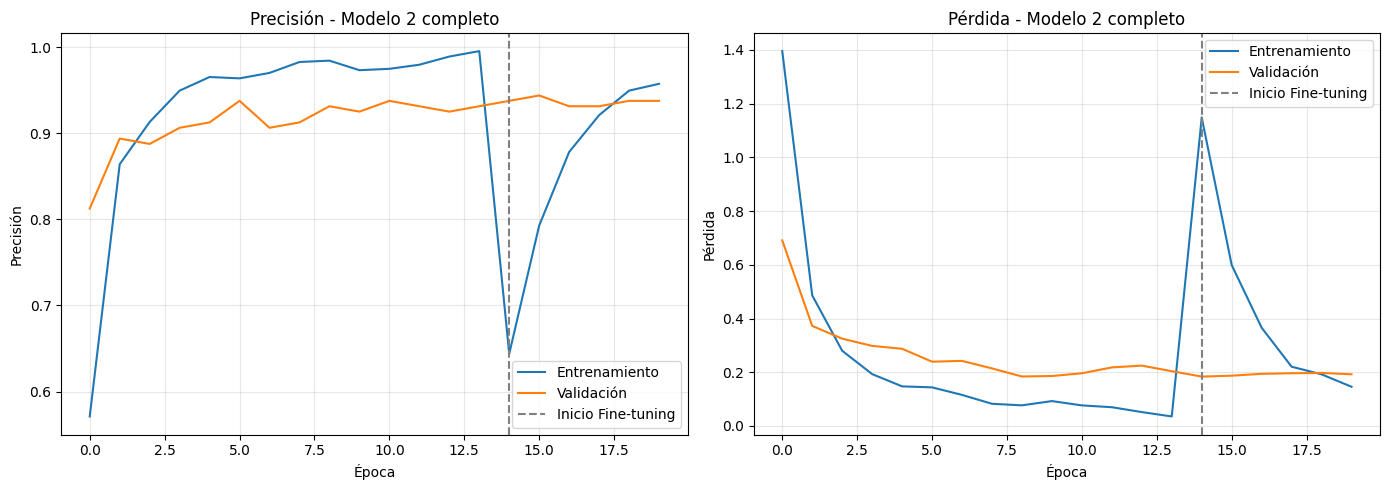

In [ ]:
# @title Gráficos comparativos: Fase 1 (congelado) vs Fase 2 (fine-tuning)

# Concatenamos el historial de ambas fases para verlo como un entrenamiento continuo
acc_total = history_tl.history['accuracy'] + history_ft.history['accuracy']
val_acc_total = history_tl.history['val_accuracy'] + history_ft.history['val_accuracy']
loss_total = history_tl.history['loss'] + history_ft.history['loss']
val_loss_total = history_tl.history['val_loss'] + history_ft.history['val_loss']

epoca_corte = len(history_tl.history['accuracy'])  # dónde empieza el fine-tuning

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc_total, label='Entrenamiento')
axes[0].plot(val_acc_total, label='Validación')
axes[0].axvline(epoca_corte, color='gray', linestyle='--', label='Inicio Fine-tuning')
axes[0].set_title('Precisión - Modelo 2 completo')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Precisión')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(loss_total, label='Entrenamiento')
axes[1].plot(val_loss_total, label='Validación')
axes[1].axvline(epoca_corte, color='gray', linestyle='--', label='Inicio Fine-tuning')
axes[1].set_title('Pérdida - Modelo 2 completo')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Pérdida')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(ruta_salida / 'grafico_modelo2_completo.png'), dpi=150)
plt.show()

###5 Codigo de Inferencia y Visualizacion

In [ ]:
# @title Función de inferencia y visualización (ambos modelos)
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

def predecir_imagen(ruta_imagen, mostrar_ambos_modelos=True):
    # Cargar imagen y redimensionar al tamaño que espera la red
    img = keras_image.load_img(ruta_imagen, target_size=TAM_IMAGEN)
    img_array = keras_image.img_to_array(img)
    img_batch = tf.expand_dims(img_array, 0)  # agregar dimensión de batch

    # --- Predicción Modelo 1 (CNN Custom) ---
    # Este modelo espera píxeles en 0-1 (por la capa Rescaling interna, ya lo maneja solo)
    pred_custom = modelo_custom.predict(img_batch, verbose=0)[0]
    clase_custom = CLASES[tf.argmax(pred_custom)]
    conf_custom = pred_custom[tf.argmax(pred_custom)] * 100

    # --- Predicción Modelo 2 (Transfer Learning) ---
    # Este modelo también maneja su propio preprocesamiento internamente (preprocess_input)
    pred_tl = model_tl.predict(img_batch, verbose=0)[0]
    clase_tl = CLASES[tf.argmax(pred_tl)]
    conf_tl = pred_tl[tf.argmax(pred_tl)] * 100

    # --- Visualización ---
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    titulo = f"Modelo 1 (Personalizado): {clase_custom} ({conf_custom:.1f}%)"
    if mostrar_ambos_modelos:
        titulo += f"\nModelo 2 (Transfer Learning): {clase_tl} ({conf_tl:.1f}%)"
    plt.title(titulo, fontsize=11)
    plt.show()

    return {"personalizado": (clase_custom, conf_custom), "transfer_learning": (clase_tl, conf_tl)}

In [ ]:
# @title Ver nombres de archivo disponibles en test (para elegir uno)
import os
clase_ejemplo = CLASES[4]  # cambiá el índice para ver otra clase
archivos = os.listdir(ruta_salida / 'test' / clase_ejemplo)
print(f"Archivos en test/{clase_ejemplo}:")
print(archivos[:10])

Archivos en test/Hipopotamos:
['hipopotamo_067.jpg', 'hipopotamo_031.jpg', 'hipopotamo_057.jpg', 'hipopotamo_055.jpg', 'hipopotamo_080.jpg', 'hipopotamo_026.jpg', '17026DB0-9344-451E-B487-F88EF2C6E72A.jpg', 'hipopotamo_011.jpg', 'hipopotamo_054.jpg', 'hipopotamo_018.jpg']


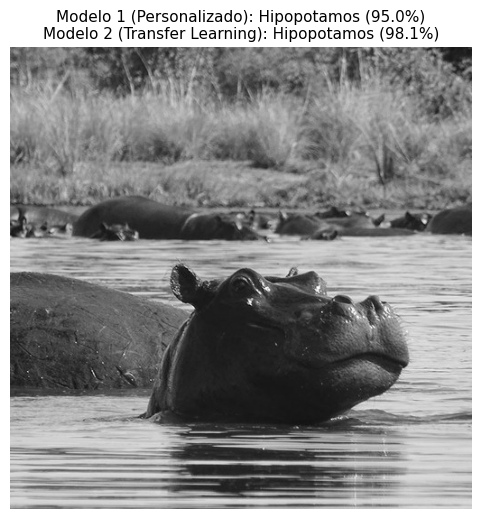

{'personalizado': ('Hipopotamos', np.float32(94.965355)), 'transfer_learning': ('Hipopotamos', np.float32(98.0531))}


In [ ]:
ruta_prueba = str(ruta_salida / 'test' / 'Hipopotamos' / 'hipopotamo_055.jpg')

resultado = predecir_imagen(ruta_prueba)
print(resultado)